In [5]:
# CELL 1 - Import Library
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [6]:
# CELL 2 - Parameter Simulasi

TOTAL_OMPRENG = 300
RANDOM_SEED = 42

# Rentang waktu (menit)
MIN_LAUK, MAX_LAUK = 0.33, 0.50
MIN_ANGKAT, MAX_ANGKAT = 0.33, 1.00
MIN_NASI, MAX_NASI = 0.33, 0.50

np.random.seed(RANDOM_SEED)

In [7]:
# CELL 3 - Generate Data

df = pd.DataFrame({
    "id": range(1, TOTAL_OMPRENG + 1),
    "lauk": np.random.uniform(MIN_LAUK, MAX_LAUK, TOTAL_OMPRENG),
    "angkat": np.random.uniform(MIN_ANGKAT, MAX_ANGKAT, TOTAL_OMPRENG),
    "nasi": np.random.uniform(MIN_NASI, MAX_NASI, TOTAL_OMPRENG),
})

df["total_waktu"] = df["lauk"] + df["angkat"] + df["nasi"]

df.head()

,id,lauk,angkat,nasi,total_waktu
0,1,0.393672,0.364627,0.358719,1.117018
1,2,0.491621,0.686008,0.377360,1.554989
2,3,0.454439,0.692226,0.360092,1.506756
3,4,0.431772,0.757078,0.345079,1.533929
4,5,0.356523,0.816481,0.350508,1.523512


In [8]:
# CELL 4 - Statistik

avg_lauk = df["lauk"].mean()
avg_angkat = df["angkat"].mean()
avg_nasi = df["nasi"].mean()

util_lauk = avg_lauk / df["total_waktu"].mean() * 100
util_angkat = avg_angkat / df["total_waktu"].mean() * 100
util_nasi = avg_nasi / df["total_waktu"].mean() * 100

print("Rata-rata Lauk:", round(avg_lauk, 3))
print("Rata-rata Angkat:", round(avg_angkat, 3))
print("Rata-rata Nasi:", round(avg_nasi, 3))

Rata-rata Lauk: 0.414
Rata-rata Angkat: 0.672
Rata-rata Nasi: 0.41


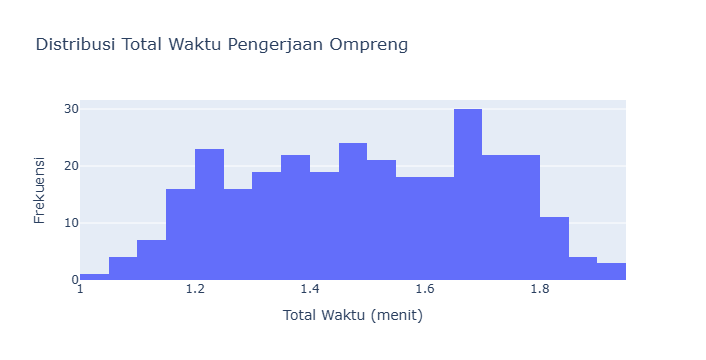

In [9]:
# CELL 5 - Histogram

fig = px.histogram(
    df,
    x="total_waktu",
    nbins=30,
    title="Distribusi Total Waktu Pengerjaan Ompreng",
)

fig.update_layout(
    xaxis_title="Total Waktu (menit)",
    yaxis_title="Frekuensi"
)

fig.show()

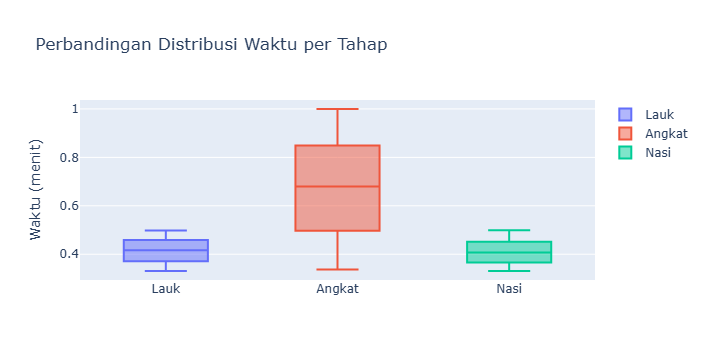

In [10]:
# CELL 6 - Boxplot

fig = go.Figure()

fig.add_trace(go.Box(y=df["lauk"], name="Lauk"))
fig.add_trace(go.Box(y=df["angkat"], name="Angkat"))
fig.add_trace(go.Box(y=df["nasi"], name="Nasi"))

fig.update_layout(
    title="Perbandingan Distribusi Waktu per Tahap",
    yaxis_title="Waktu (menit)"
)

fig.show()

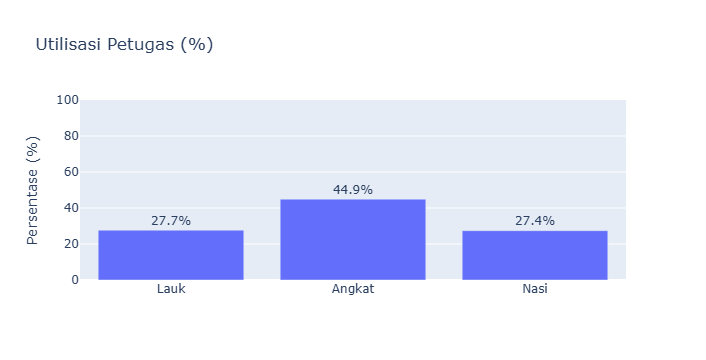

In [11]:
# CELL 7 - Utilisasi

fig = go.Figure()

fig.add_trace(go.Bar(
    x=["Lauk", "Angkat", "Nasi"],
    y=[util_lauk, util_angkat, util_nasi],
    text=[f"{util_lauk:.1f}%", f"{util_angkat:.1f}%", f"{util_nasi:.1f}%"],
    textposition="outside"
))

fig.update_layout(
    title="Utilisasi Petugas (%)",
    yaxis=dict(range=[0, 100]),
    yaxis_title="Persentase (%)"
)

fig.show()

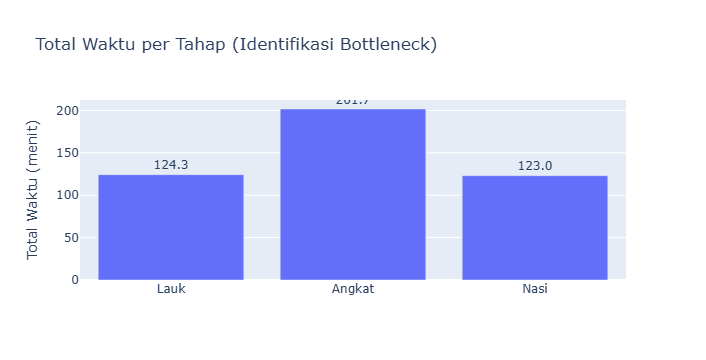

In [12]:
# CELL 8 - Bottleneck

total_lauk = df["lauk"].sum()
total_angkat = df["angkat"].sum()
total_nasi = df["nasi"].sum()

fig = go.Figure()

fig.add_trace(go.Bar(
    x=["Lauk", "Angkat", "Nasi"],
    y=[total_lauk, total_angkat, total_nasi],
    text=[f"{total_lauk:.1f}", f"{total_angkat:.1f}", f"{total_nasi:.1f}"],
    textposition="outside"
))

fig.update_layout(
    title="Total Waktu per Tahap (Identifikasi Bottleneck)",
    yaxis_title="Total Waktu (menit)"
)

fig.show()

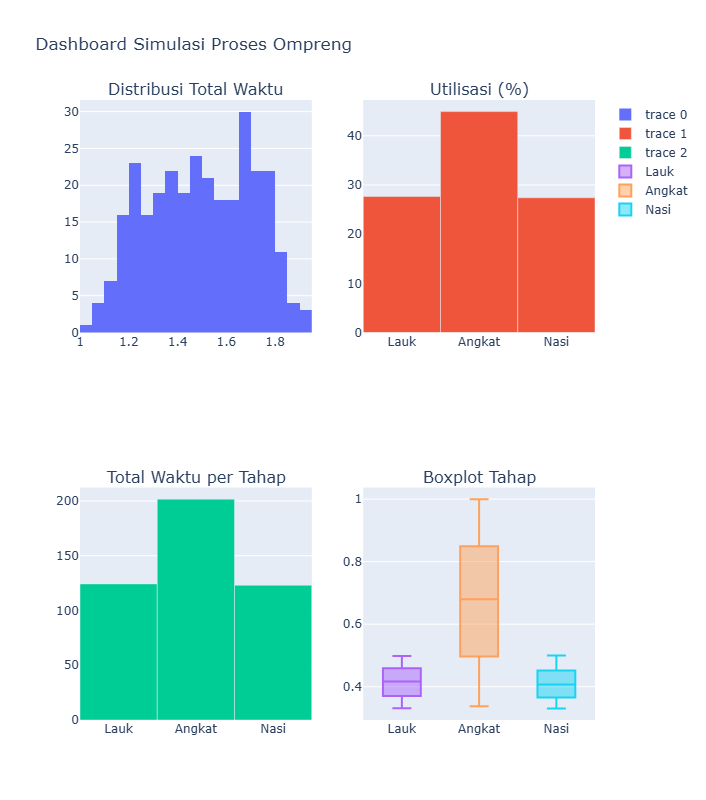

In [13]:
# CELL 9 - Dashboard Gabungan

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Distribusi Total Waktu",
        "Utilisasi (%)",
        "Total Waktu per Tahap",
        "Boxplot Tahap"
    )
)

# Histogram
fig.add_trace(
    go.Histogram(x=df["total_waktu"]),
    row=1, col=1
)

# Utilisasi
fig.add_trace(
    go.Bar(x=["Lauk", "Angkat", "Nasi"],
           y=[util_lauk, util_angkat, util_nasi]),
    row=1, col=2
)

# Total Tahap
fig.add_trace(
    go.Bar(x=["Lauk", "Angkat", "Nasi"],
           y=[total_lauk, total_angkat, total_nasi]),
    row=2, col=1
)

# Boxplot
fig.add_trace(go.Box(y=df["lauk"], name="Lauk"), row=2, col=2)
fig.add_trace(go.Box(y=df["angkat"], name="Angkat"), row=2, col=2)
fig.add_trace(go.Box(y=df["nasi"], name="Nasi"), row=2, col=2)

fig.update_layout(
    height=800,
    title_text="Dashboard Simulasi Proses Ompreng"
)

fig.show()